# 01 — Data Acquisition
We will first build the causal survival pipeline and implement BNP weighting. Once everything is debugged, we'll work on KM-extraction

In [2]:
!pip install -r ../requirements.txt

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import requests
import pandas as pd
import json
from pathlib import Path

# Create output folders
Path("../data/raw").mkdir(parents=True, exist_ok=True)
Path("../data/processed").mkdir(parents=True, exist_ok=True)

In [4]:
# Prototyping with sample dataset before reconstruction
# Load a standard survival dataset (for pipeline prototyping)
from lifelines.datasets import load_rossi
df = load_rossi()
df.head()

,week,arrest,fin,age,race,wexp,mar,paro,prio
0,20,1,0,27,1,0,0,1,3
1,17,1,0,18,1,0,0,1,8
2,25,1,0,19,0,1,0,1,13
3,52,0,1,23,1,1,1,1,1
4,52,0,0,19,0,1,0,1,3


In [5]:
# Format data into (T (time), E (event indicator), A (treatment), X (covariates))
df_surv = df.copy()
df_surv = df_surv.rename(columns={
    "week": "time",
    "arrest": "event",
    "fin": "treatment"
})

# Basic sanity check
print(df_surv.shape)
df_surv[["time", "event", "treatment"]].head()

(432, 9)


,time,event,treatment
0,20,1,0
1,17,1,0
2,25,1,0
3,52,0,1
4,52,0,0


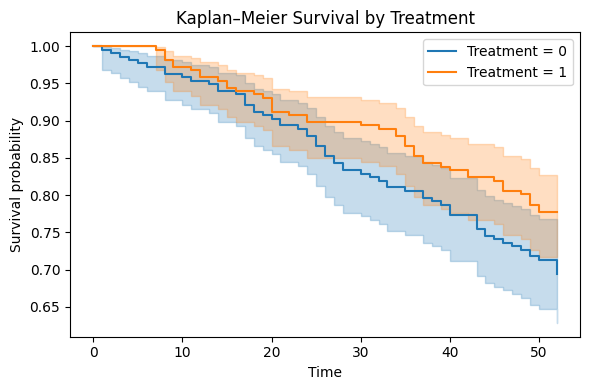

In [6]:
# Kaplan–Meier survival curves by treatment
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()
plt.figure(figsize=(6,4))
for a in [0, 1]:
    mask = df_surv["treatment"] == a
    kmf.fit(
        durations=df_surv.loc[mask, "time"],
        event_observed=df_surv.loc[mask, "event"],
        label=f"Treatment = {a}"
    )
    kmf.plot_survival_function()

plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.title("Kaplan–Meier Survival by Treatment")
plt.tight_layout()
plt.show()

We see that treatment(1) is consistently higher in survival compared to (0). This likely means our causal estimand $S^1(t_0) - S^0(t_0)$ is likely to be positive. Next we implement a naive estimator: a target estimand at 30 weeks.

In [7]:
# Survival probability at fixed time t0
t0 = 30

def survival_at_t(kmf, t):
    return kmf.survival_function_at_times(t).values[0]

results = {}

for a in [0, 1]:
    mask = df_surv["treatment"] == a
    kmf.fit(
        durations=df_surv.loc[mask, "time"],
        event_observed=df_surv.loc[mask, "event"]
    )
    results[a] = survival_at_t(kmf, t0)

S0 = results[0]
S1 = results[1]
delta = S1 - S0

print(f"S^0({t0}) = {S0:.4f}")
print(f"S^1({t0}) = {S1:.4f}")
print(f"Δ({t0}) = {delta:.4f}")

S^0(30) = 0.8287
S^1(30) = 0.8935
Δ(30) = 0.0648


We will now create a nonparametric prior over the population where each draw of $w$ is one plausible population consistent with observed data. Later we will impose constraints like Table 1 and then average

In [8]:
# Bayesian nonparametric weights (Dirichlet)
import numpy as np

n = len(df_surv)
alpha = 1.0 # concentration parameter (can tune later)
w = np.random.dirichlet(alpha * np.ones(n)) # sample weights

# attach to dataframe
df_surv["w"] = w
df_surv["w"].head()

0    0.000613
1    0.003255
2    0.001232
3    0.001279
4    0.009073
Name: w, dtype: float64

In [9]:
# Weighted survival probability at t0 using BNP weights
t0 = 30

df_surv["surv_indicator"] = (df_surv["time"] > t0).astype(int)

S0_w = (
    df_surv.loc[df_surv["treatment"] == 0, "w"]
    * df_surv.loc[df_surv["treatment"] == 0, "surv_indicator"]
).sum() / df_surv.loc[df_surv["treatment"] == 0, "w"].sum()

S1_w = (
    df_surv.loc[df_surv["treatment"] == 1, "w"]
    * df_surv.loc[df_surv["treatment"] == 1, "surv_indicator"]
).sum() / df_surv.loc[df_surv["treatment"] == 1, "w"].sum()

delta_w = S1_w - S0_w

print(f"Weighted S^0({t0}) = {S0_w:.4f}")
print(f"Weighted S^1({t0}) = {S1_w:.4f}")
print(f"Weighted Δ({t0}) = {delta_w:.4f}")

Weighted S^0(30) = 0.8862
Weighted S^1(30) = 0.8606
Weighted Δ(30) = -0.0255


The sign switch is expected since we are implicity changing the covariate distribution. These weights are unconstrained, and we have not used auxiliary summary information, so all possible populations are equally plausible. We will now average over many weight draws

In [10]:
# Repeat BNP weighting many times (posterior simulation)
n_draws = 200

deltas = []

for _ in range(n_draws):
    w = np.random.dirichlet(alpha * np.ones(n))
    
    df_surv["w"] = w
    df_surv["surv_indicator"] = (df_surv["time"] > t0).astype(int)

    S0_w = (
        df_surv.loc[df_surv["treatment"] == 0, "w"]
        * df_surv.loc[df_surv["treatment"] == 0, "surv_indicator"]
    ).sum() / df_surv.loc[df_surv["treatment"] == 0, "w"].sum()

    S1_w = (
        df_surv.loc[df_surv["treatment"] == 1, "w"]
        * df_surv.loc[df_surv["treatment"] == 1, "surv_indicator"]
    ).sum() / df_surv.loc[df_surv["treatment"] == 1, "w"].sum()

    deltas.append(S1_w - S0_w)

deltas = np.array(deltas)

print("Mean Δ:", deltas.mean())
print("Std Δ:", deltas.std())

Mean Δ: 0.06340418572593551
Std Δ: 0.031278213162141875


## Constrained BNP Weights

In [13]:
# Stabilize the weighting step by standardizing covariates

covariates = ["age", "race", "wexp", "mar", "paro", "prio"]

X_raw = df_surv[covariates].values
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0, ddof=0)
X_std[X_std == 0] = 1.0

X_scaled = (X_raw - X_mean) / X_std

# use a nontrivial target: slightly shifted Table 1 moments
target_raw = df_surv[covariates].mean().copy()
target_raw["age"] += 2.0
target_raw["race"] -= 0.05
target_raw["wexp"] -= 0.05

target_scaled = (target_raw.values - X_mean) / X_std

def compute_weights(theta):
    logits = X_scaled @ theta
    logits = np.clip(logits, -50, 50)   # numerical stability
    w = np.exp(logits)
    w /= w.sum()
    return w

def objective(theta):
    w = compute_weights(theta)
    moments = w @ X_scaled
    return np.sum((moments - target_scaled) ** 2)

theta0 = np.zeros(X_scaled.shape[1])
res = minimize(objective, theta0, method="BFGS")

theta_hat = res.x
w_constrained = compute_weights(theta_hat)
df_surv["w_constrained"] = w_constrained

matched_raw = df_surv[covariates].multiply(df_surv["w_constrained"], axis=0).sum()

print("Target:\n", target_raw)
print("\nMatched:\n", matched_raw)
print("\nOptimization success:", res.success)

Target:
 age     26.597222
race     0.827315
wexp     0.521759
mar      0.122685
paro     0.618056
prio     2.983796
dtype: float64

Matched:
 age     26.597224
race     0.827315
wexp     0.521760
mar      0.122685
paro     0.618057
prio     2.983803
dtype: float64

Optimization success: True


/var/folders/38/22n3rn6s7gjdhyf__np8757r0000gn/T/ipykernel_6233/1851562130.py:21: RuntimeWarning: overflow encountered in matmul
  logits = X_scaled @ theta


The matching worked, so no backtrack needed yet. The overflow warning is from the optimizer trying extreme intermediate theta values; because we clip logits, the final weights are still usable. If it becomes persistent, the next refinement would be bounded optimization or a small ridge penalty

In [14]:
# Constrained-weight survival estimate at t0

t0 = 30

df_surv["surv_indicator"] = (df_surv["time"] > t0).astype(int)

S0_c = (
    df_surv.loc[df_surv["treatment"] == 0, "w_constrained"]
    * df_surv.loc[df_surv["treatment"] == 0, "surv_indicator"]
).sum() / df_surv.loc[df_surv["treatment"] == 0, "w_constrained"].sum()

S1_c = (
    df_surv.loc[df_surv["treatment"] == 1, "w_constrained"]
    * df_surv.loc[df_surv["treatment"] == 1, "surv_indicator"]
).sum() / df_surv.loc[df_surv["treatment"] == 1, "w_constrained"].sum()

delta_c = S1_c - S0_c

print(f"Constrained S^0({t0}) = {S0_c:.4f}")
print(f"Constrained S^1({t0}) = {S1_c:.4f}")
print(f"Constrained Δ({t0}) = {delta_c:.4f}")

Constrained S^0(30) = 0.8188
Constrained S^1(30) = 0.9021
Constrained Δ(30) = 0.0833


Shifting the target population toward older age / lower race / lower work-experience changed the estimated treatment effect, which is exactly the behavior we expect

In [15]:
# Inspect weight concentration / positivity
print("Min weight:", df_surv["w_constrained"].min())
print("Max weight:", df_surv["w_constrained"].max())
print("Effective sample size:",
      1.0 / np.sum(df_surv["w_constrained"] ** 2))

Min weight: 0.000986589868598474
Max weight: 0.008734137843611982
Effective sample size: 358.53616122158184


The ESS is 359 out of 432, so our reweighting is very stable. Now we have one constrained solution, but we want uncertainty over weights, so we'll sample around the constrained solution next

In [16]:
# Sample BNP weights around constrained solution

n_draws = 200
deltas_constrained = []

alpha = 200  # concentration (higher = tighter around constraint)

base_w = df_surv["w_constrained"].values

for _ in range(n_draws):
    # Dirichlet centered at constrained weights
    w = np.random.dirichlet(alpha * base_w)
    
    df_surv["w"] = w
    df_surv["surv_indicator"] = (df_surv["time"] > t0).astype(int)

    S0_w = (
        df_surv.loc[df_surv["treatment"] == 0, "w"]
        * df_surv.loc[df_surv["treatment"] == 0, "surv_indicator"]
    ).sum() / df_surv.loc[df_surv["treatment"] == 0, "w"].sum()

    S1_w = (
        df_surv.loc[df_surv["treatment"] == 1, "w"]
        * df_surv.loc[df_surv["treatment"] == 1, "surv_indicator"]
    ).sum() / df_surv.loc[df_surv["treatment"] == 1, "w"].sum()

    deltas_constrained.append(S1_w - S0_w)

deltas_constrained = np.array(deltas_constrained)

print("Mean Δ:", deltas_constrained.mean())
print("Std Δ:", deltas_constrained.std())

Mean Δ: 0.08262115726913169
Std Δ: 0.04914747911860863


Auxiliary summary information changes both the estimated effect and its uncertainty, depending on how restrictive the implied population is.

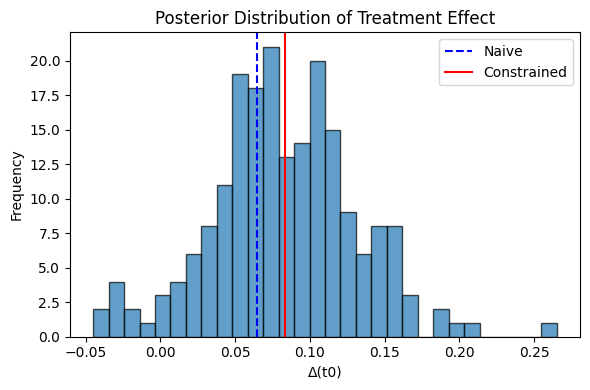

In [17]:
# Posterior distribution of Δ

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(deltas_constrained, bins=30, alpha=0.7, edgecolor="black")

plt.axvline(delta, linestyle="--", label="Naive", color="blue")
plt.axvline(delta_c, linestyle="-", label="Constrained", color="red")

plt.xlabel("Δ(t0)")
plt.ylabel("Frequency")
plt.title("Posterior Distribution of Treatment Effect")

plt.legend()
plt.tight_layout()
plt.show()